In [1]:
import scanpy as sc
import seaborn as sns
import harmonypy as hm
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import palantir
import pandas as pd

In [2]:
adata = sc.read("../results/adata/09-annotation.h5ad")

In [3]:
adata = adata[adata.obs["cell_type"] == "muscle"].copy()

In [4]:
adata.X = adata.layers["soupx_rounded"]

In [5]:
adata.obs["sample"].value_counts()

sample
D5_C    418
D7_D    326
D5_B    216
D5_A    198
D7_C    149
D0_A     28
D0_B     21
D2_D      1
D2_C      1
Name: count, dtype: int64

In [6]:
print(f"{len(adata.var)} genes before filtering")
sc.pp.filter_genes(adata, min_counts=10)
print(f"{len(adata.var)} genes after filtering")

31656 genes before filtering
14995 genes after filtering


In [7]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

<Axes: ylabel='Count'>

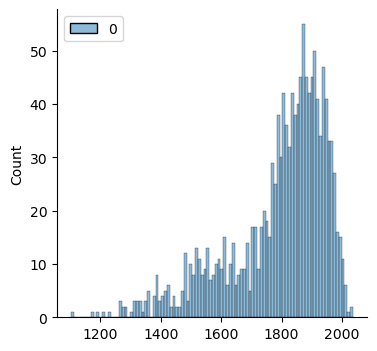

In [8]:
sns.histplot(adata.X.sum(1), bins=100)

In [9]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000)

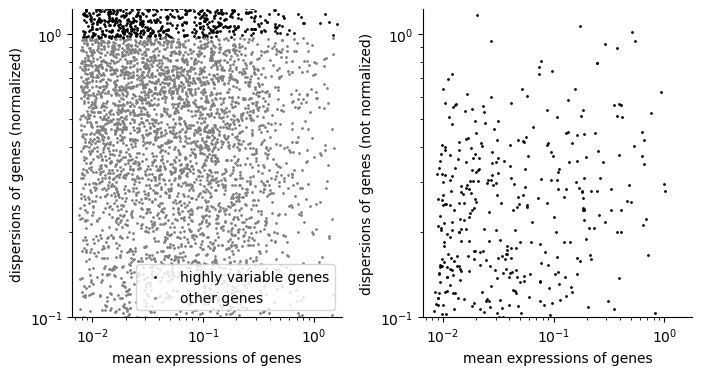

In [10]:
sc.pl.highly_variable_genes(adata, log=True)

In [11]:
sc.pp.pca(adata, svd_solver="arpack", mask_var="highly_variable")

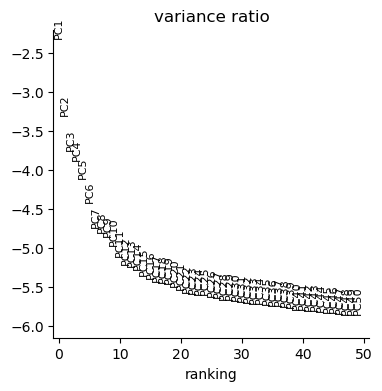

In [12]:
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

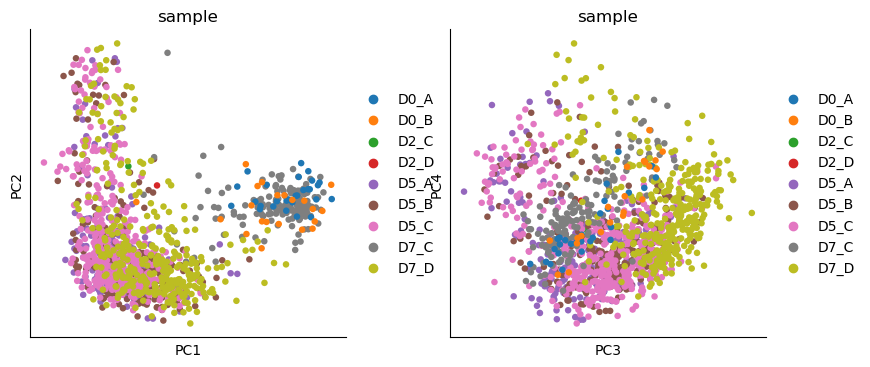

In [13]:
sc.pl.pca_scatter(adata, color="sample", components=["1,2", "3,4"])

In [14]:
harmony_out = hm.run_harmony(adata.obsm["X_pca"], adata.obs, "sample", max_iter_harmony=30)
adata.obsm['X_pca_harmony'] = harmony_out.Z_corr

/home/FCAM/kcobb/.miniforge/envs/single-cell/lib/python3.11/site-packages/torch/cuda/__init__.py:184: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0
2026-06-22 15:02:33,252 - harmonypy - INFO - Running Harmony (PyTorch on cpu)
2026-06-22 15:02:33,253 - harmonypy - INFO -   Parameters:
2026-06-22 15:02:33,253 - harmonypy - INFO -     max_iter_harmony: 30
2026-06-22 15:02:33,254 - harmonypy - INFO -     max_iter_kmeans: 20
2026-06-22 15:02:33,255 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-06-22 15:02:33,255 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-06-22 15:02:33,255 - harmonypy - INFO -     nclust: 45
2026-06-22 15:02:33,256 - harmonypy - INFO -     block_size: 0.05
2026-06-22 15:02:33

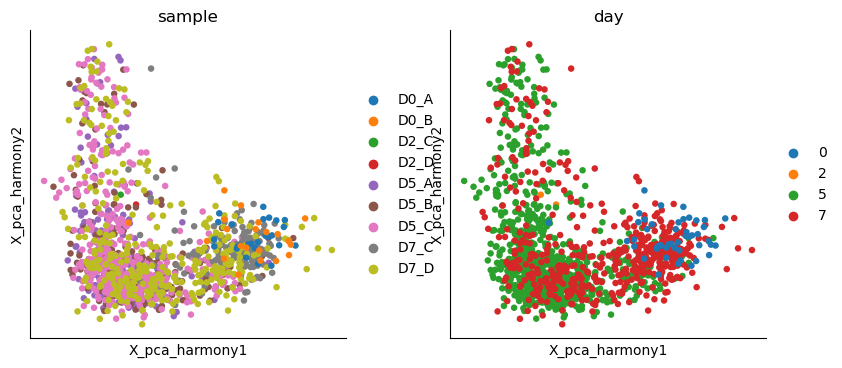

In [15]:
sc.pl.embedding(adata, basis="X_pca_harmony", color=["sample", "day"])

In [16]:
# sc.pp.neighbors(adata, n_pcs=40)
sc.pp.neighbors(adata, n_pcs=40, use_rep='X_pca_harmony')
sc.tl.umap(adata)

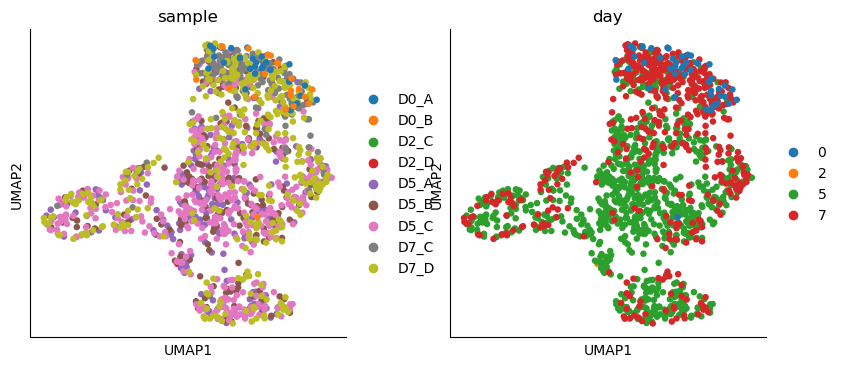

In [17]:
sc.pl.umap(adata, ncols=3, color=["sample", "day"])

In [18]:
sc.tl.leiden(adata, key_added="cluster", resolution=0.15, flavor="igraph")

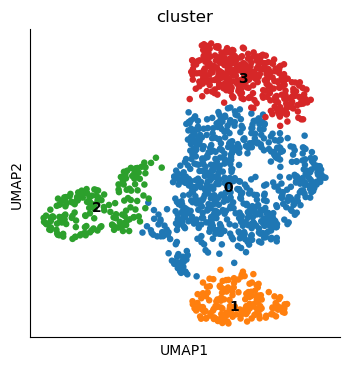

In [19]:
sc.pl.umap(adata, color="cluster", legend_loc="on data")

MuSCs & progenitors:


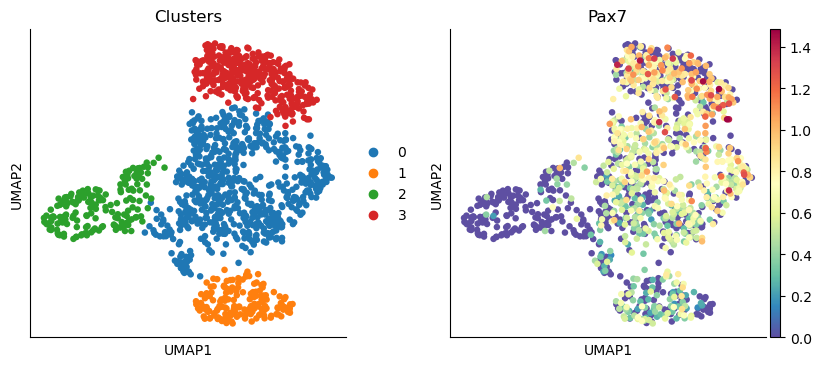

Mature skeletal muscle:


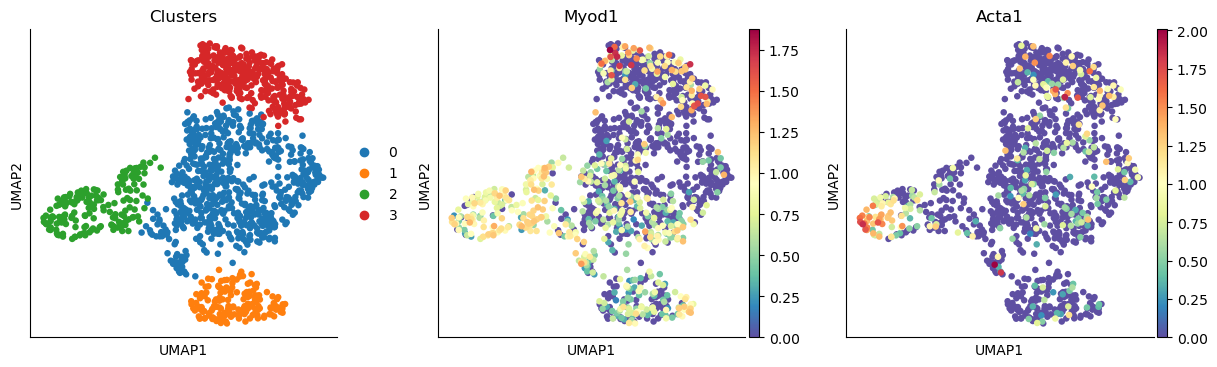

In [20]:
marker_genes = {
    "MuSCs & progenitors": ["Pax7"],
    "Mature skeletal muscle": ["Myod1", "Acta1"],
}
for cell_type, genes in marker_genes.items():
    print(f"{cell_type}:")
    sc.pl.umap(adata, color=["cluster"] + genes, title=["Clusters"] + genes)

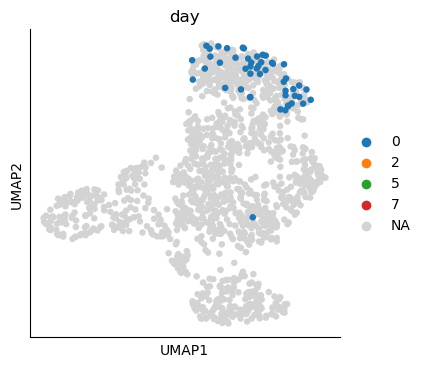

In [21]:
sc.pl.umap(adata, color="day", mask_obs=(adata.obs["day"] == 0))

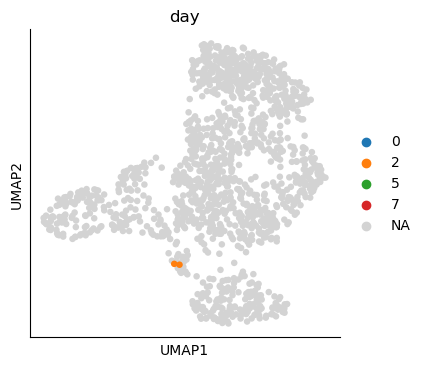

In [22]:
sc.pl.umap(adata, color="day", mask_obs=(adata.obs["day"] == 2))

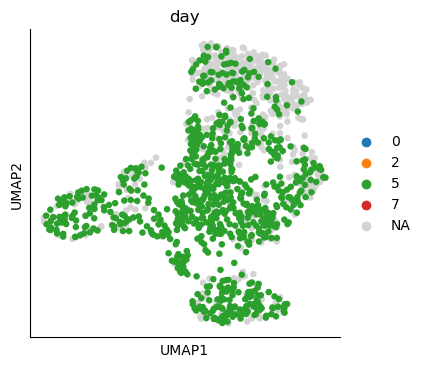

In [23]:
sc.pl.umap(adata, color="day", mask_obs=(adata.obs["day"] == 5))

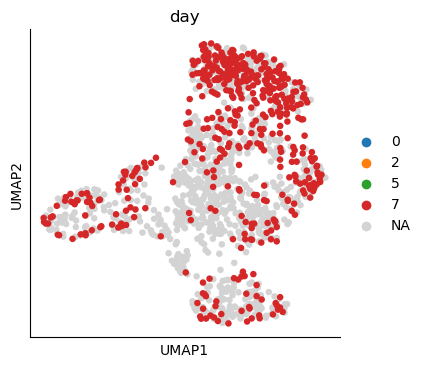

In [24]:
sc.pl.umap(adata, color="day", mask_obs=(adata.obs["day"] == 7))

In [25]:
sc.tl.score_genes(
    adata,
    gene_list=["Pax7", "Foxo3", "Vcam1"],
    score_name="quiescence_score"
)

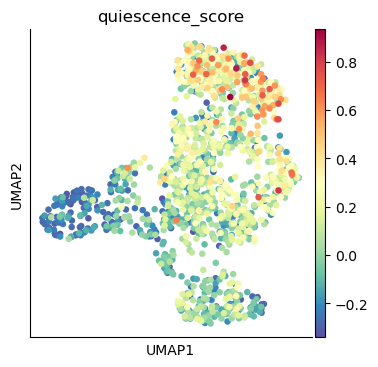

In [26]:
sc.pl.umap(adata, color="quiescence_score")

In [27]:
adata.uns["iroot"] = root_ix = np.argmax(adata.obs["quiescence_score"])

In [28]:
sc.tl.diffmap(adata)

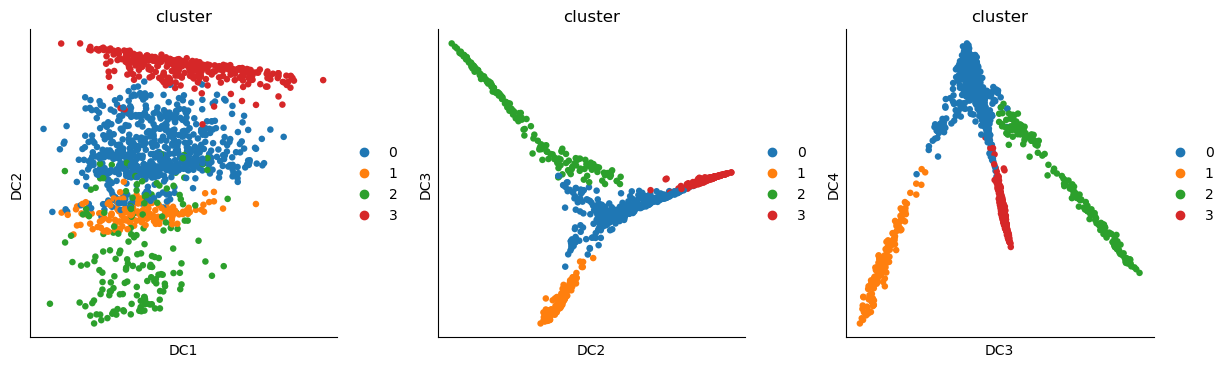

In [29]:
sc.pl.diffmap(
    adata,
    color="cluster",
    components=["1,2", "2,3", "3,4"])

<Axes: >

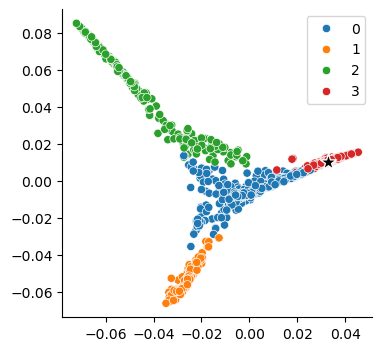

In [30]:
# Index for diffusion component is component-1
diff_comp1 = 1
diff_comp2 = 2
f, ax = plt.subplots()
sns.scatterplot(x=adata.obsm["X_diffmap"][:,diff_comp1], 
                y=adata.obsm["X_diffmap"][:,diff_comp2],  
                hue=adata.obs["cluster"], ax=ax)

sns.scatterplot(x=[adata.obsm["X_diffmap"][root_ix, diff_comp1]],
                y=[adata.obsm["X_diffmap"][root_ix,diff_comp2]],
                marker="*", c="black", s=150, ax=ax)

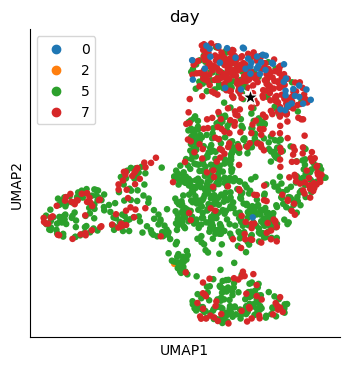

In [31]:
f, ax = plt.subplots()
sc.pl.umap(adata, color="day", ax=ax, show=False)
# sc.pl.embedding(adata, basis="X_pca_harmony", color="day", ax=ax, show=False)
sns.scatterplot(
    x=[
        adata.obsm["X_umap"][root_ix][0],
      ],
    y=[
        adata.obsm["X_umap"][root_ix][1],
      ],
    marker="*", c="black", s=150, ax=ax)
plt.show()

In [32]:
# Index for diffusion component is component-1
root_ix = adata.obsm["X_diffmap"][:,1].argmax()
adata.uns["iroot"] = root_ix

term1 = adata.obsm["X_diffmap"][:,2].argmax()
term2 = adata.obsm["X_diffmap"][:,2].argmin()

<Axes: >

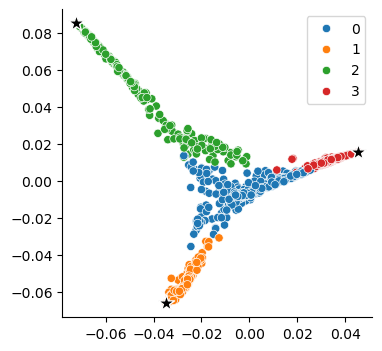

In [33]:
# Index for diffusion component is component-1
diff_comp1 = 1
diff_comp2 = 2
f, ax = plt.subplots()
sns.scatterplot(x=adata.obsm["X_diffmap"][:,diff_comp1], 
                y=adata.obsm["X_diffmap"][:,diff_comp2],  
                hue=adata.obs["cluster"], ax=ax)

sns.scatterplot(x=[adata.obsm["X_diffmap"][root_ix, diff_comp1]],
                y=[adata.obsm["X_diffmap"][root_ix, diff_comp2]],
                marker="*", c="black", s=150, ax=ax)

sns.scatterplot(x=[adata.obsm["X_diffmap"][term1, diff_comp1]],
                y=[adata.obsm["X_diffmap"][term1, diff_comp2]],
                marker="*", c="black", s=150, ax=ax)

sns.scatterplot(x=[adata.obsm["X_diffmap"][term2, diff_comp1]],
                y=[adata.obsm["X_diffmap"][term2, diff_comp2]],
                marker="*", c="black", s=150, ax=ax)


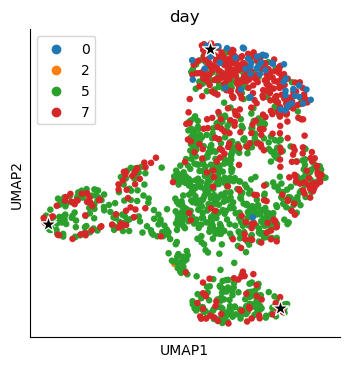

In [34]:
f, ax = plt.subplots()
sc.pl.umap(adata, color="day", ax=ax, show=False)
# sc.pl.embedding(adata, basis="X_pca_harmony", color="day", ax=ax, show=False)
sns.scatterplot(
    x=[
        adata.obsm["X_umap"][root_ix][0],
        adata.obsm["X_umap"][term1][0],
        adata.obsm["X_umap"][term2][0],
      ],
    y=[
        adata.obsm["X_umap"][root_ix][1],
        adata.obsm["X_umap"][term1][1],
        adata.obsm["X_umap"][term2][1],
      ],
    marker="*", c="black", s=150, ax=ax)
plt.show()

In [35]:
sc.tl.dpt(adata)

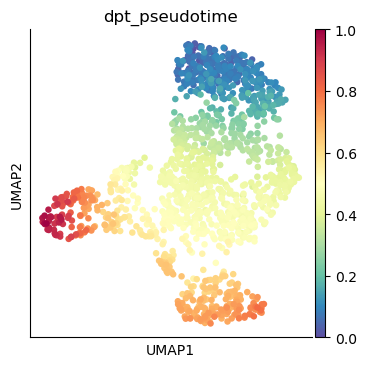

In [36]:
sc.pl.umap(adata, color="dpt_pseudotime")

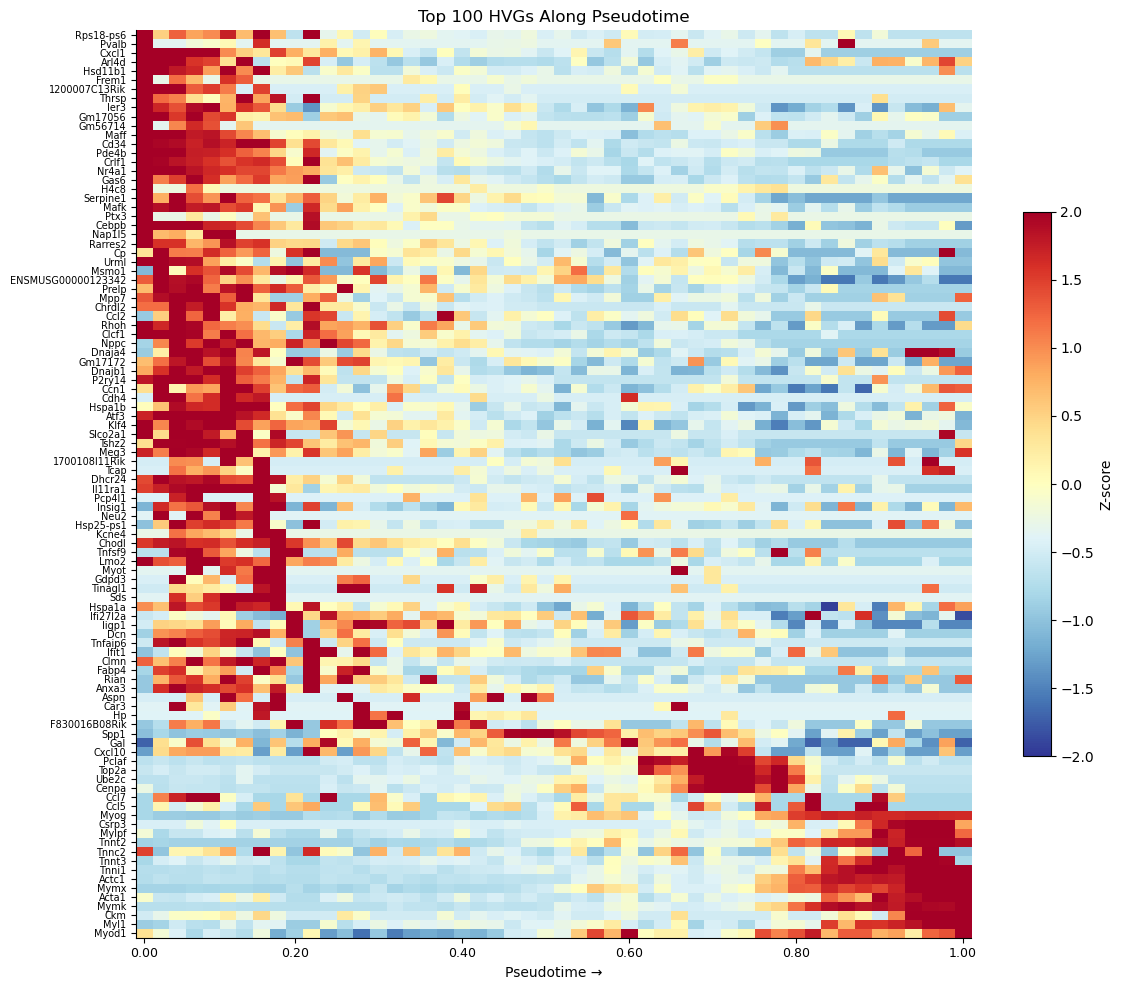

In [37]:
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d

N = 100 # Number of genes
n_bins = 50 # Number of bins
smooth_window = 1

# Select top N highly variable genes by normalized dispersion
top_genes = (
    adata.var[adata.var["highly_variable"]]
    .nlargest(N, "dispersions_norm")
    .index.tolist()
)

# Extract expression matrix
X = adata[:, top_genes].X
if hasattr(X, "toarray"):
    X = X.toarray()
X = np.array(X, dtype=float)

# Sort cells by pseudotime (drop NaN cells like the root)
pt = adata.obs["dpt_pseudotime"].values
valid = np.isfinite(pt)
X, pt = X[valid], pt[valid]
order = np.argsort(pt)
X_sorted, pt_sorted = X[order], pt[order]

# Bin cells along pseudotime and average
bins = np.linspace(pt_sorted.min(), pt_sorted.max(), n_bins + 1)
bin_idx = np.clip(np.digitize(pt_sorted, bins) - 1, 0, n_bins - 1)
X_binned = np.array([X_sorted[bin_idx == b].mean(axis=0) if (bin_idx == b).any()
                     else np.zeros(len(top_genes)) for b in range(n_bins)])

# Smooth and z-score each gene
X_binned = uniform_filter1d(X_binned, size=smooth_window, axis=0)
std = X_binned.std(axis=0)
std[std == 0] = 1
X_z = (X_binned - X_binned.mean(axis=0)) / std

# Order genes by peak expression bin
gene_order = np.argsort(np.argmax(X_z, axis=0))
X_z = X_z[:, gene_order]
genes_ordered = [top_genes[i] for i in gene_order]

# Plot
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(X_z.T, aspect="auto", cmap="RdYlBu_r", vmin=-2, vmax=2)
ax.set_yticks(range(len(genes_ordered)))
ax.set_yticklabels(genes_ordered, fontsize=7)
ax.set_xlabel("Pseudotime →")
ax.set_title(f"Top {N} HVGs Along Pseudotime")
xtick_pos = np.linspace(0, n_bins - 1, 6, dtype=int)
ax.set_xticks(xtick_pos)
ax.set_xticklabels([f"{pt_sorted.min() + (pt_sorted.max() - pt_sorted.min()) * i / 5:.2f}"
                    for i in range(6)], fontsize=9)
plt.colorbar(im, ax=ax, shrink=0.6, label="Z-score")
plt.tight_layout()
plt.show()

## Palantir

In [38]:
dm_res = palantir.utils.run_diffusion_maps(adata, n_components=5)

In [39]:
ms_data = palantir.utils.determine_multiscale_space(adata)

In [40]:
imputed_X = palantir.utils.run_magic_imputation(adata)

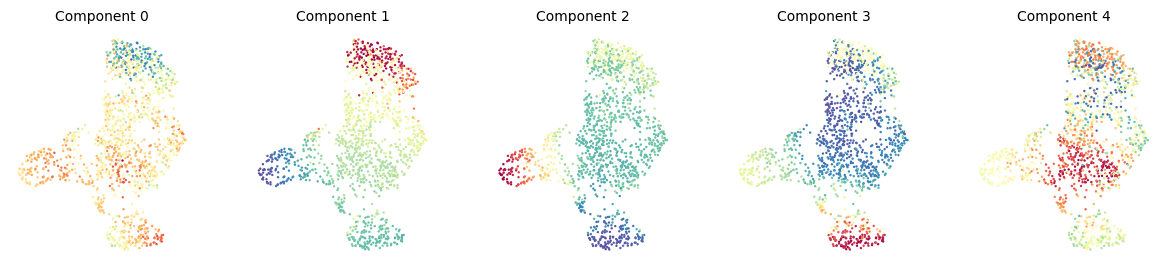

In [41]:
palantir.plot.plot_diffusion_components(adata)
plt.show()



In [42]:
start_cell = adata.obs_names[root_ix]
pr_res = palantir.core.run_palantir(adata, start_cell, num_waypoints=500)

Sampling and flocking waypoints...
Time for determining waypoints: 5.631446838378906e-05 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.005641253789265951 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9999
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...


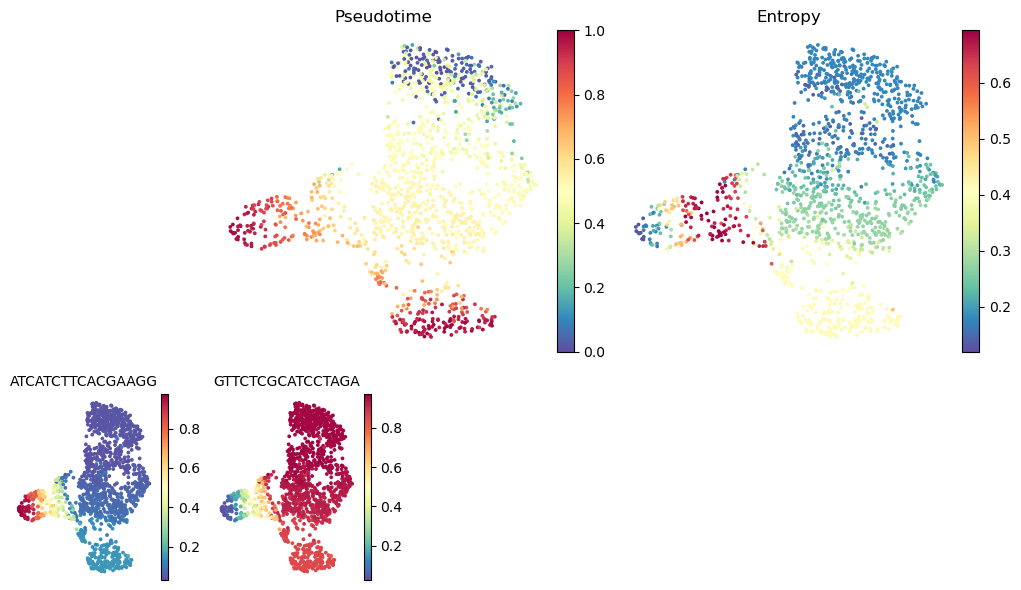

In [43]:
palantir.plot.plot_palantir_results(adata, s=3)
plt.show()

In [44]:
terminal_cell1 = adata.obs_names[term1]
terminal_cell2 = adata.obs_names[term2]

terminal_states = {
    "State1": adata.obs_names[term1], 
    "State2": adata.obs_names[term2]
}

pr_res = palantir.core.run_palantir(adata, start_cell, num_waypoints=500, terminal_states=[terminal_cell1, terminal_cell2])

Sampling and flocking waypoints...
Time for determining waypoints: 5.1581859588623046e-05 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.004101248582204183 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9999
Entropy and branch probabilities...
Markov chain construction...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...


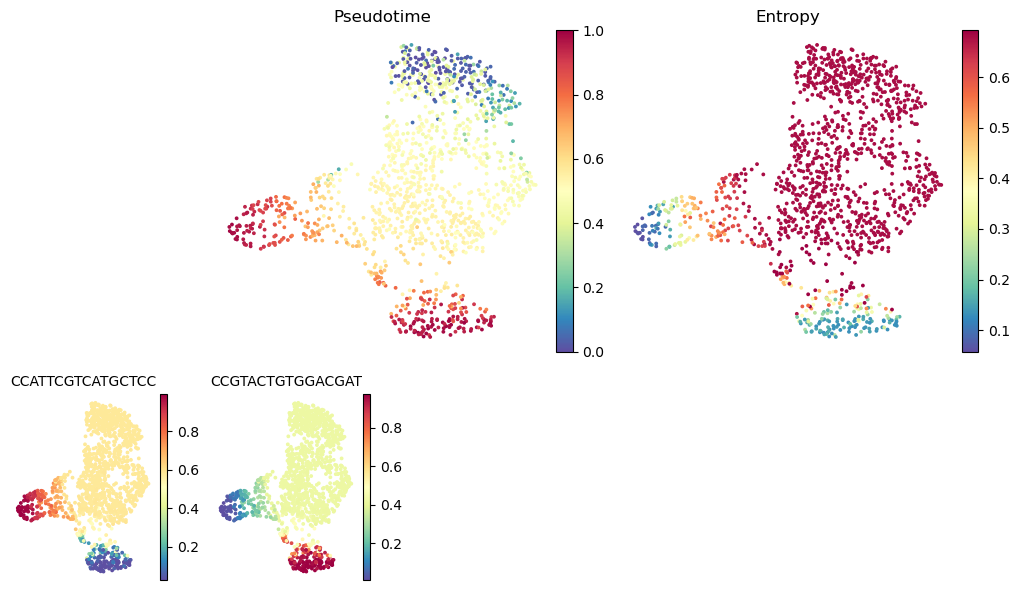

In [45]:
palantir.plot.plot_palantir_results(adata, s=3)
plt.show()

In [46]:
masks = palantir.presults.select_branch_cells(adata, q=.01, eps=.01)

In [47]:
masks[:,0]

array([False, False, False, ...,  True,  True,  True], shape=(1358,))

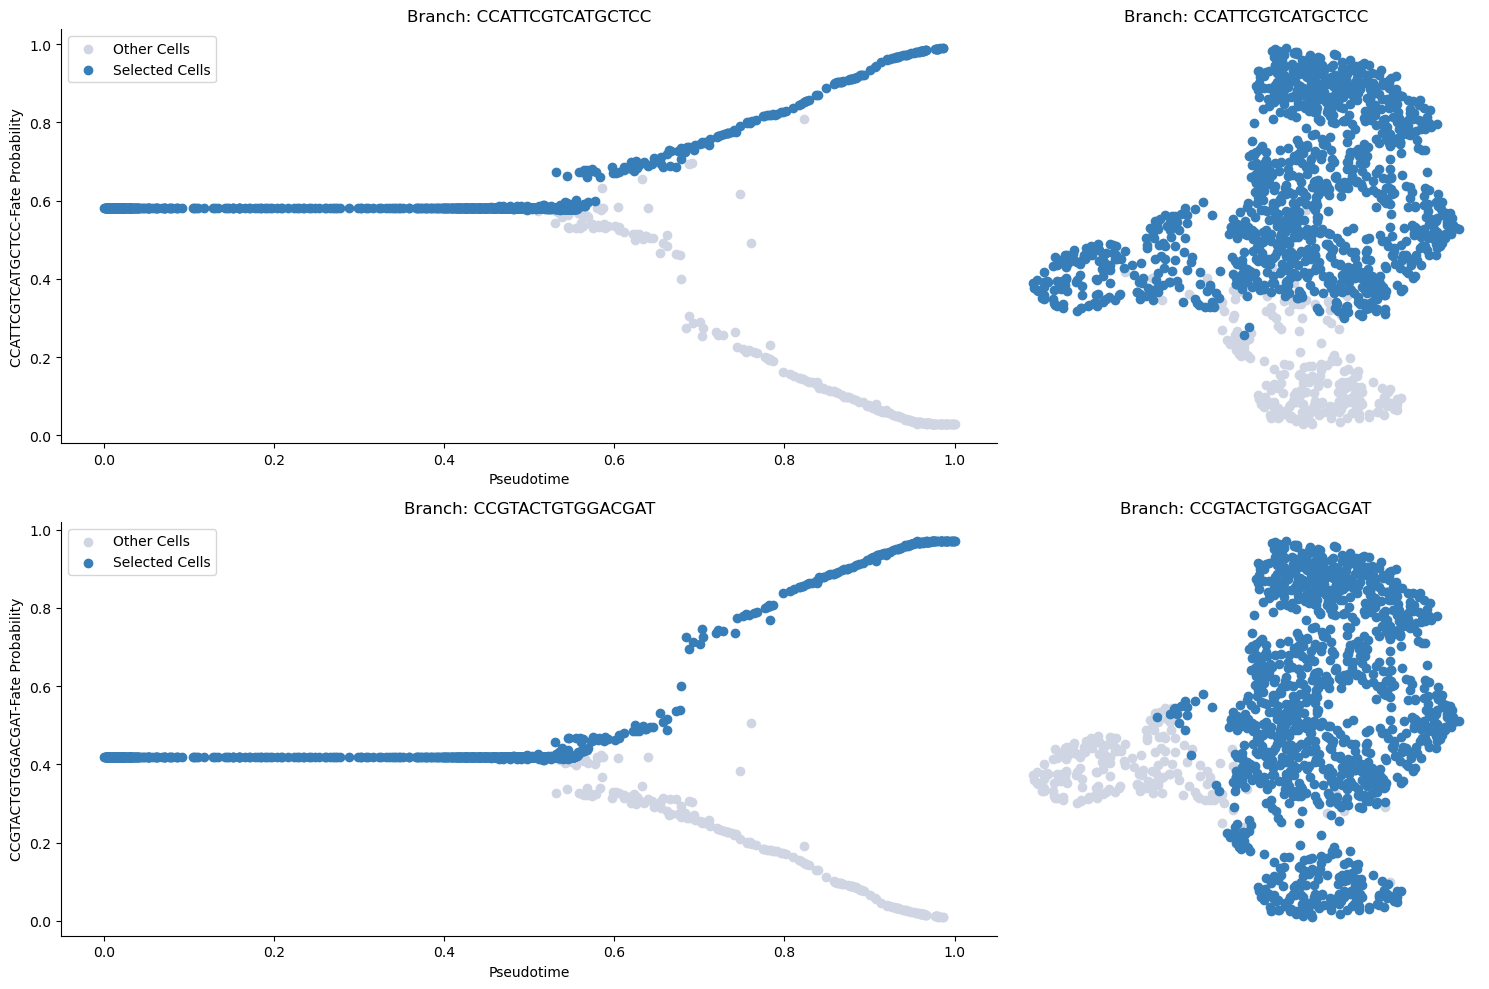

In [48]:
palantir.plot.plot_branch_selection(adata)
plt.show()

[2026-06-22 15:03:14,660] [INFO    ] Using sparse Gaussian Process since n_landmarks (50) < n_samples (1,130) and rank = 1.0.
[2026-06-22 15:03:14,661] [INFO    ] Using covariance function Matern52(ls=0.9287169575691223).
[2026-06-22 15:03:14,683] [INFO    ] Computing 50 landmarks with k-means clustering (random_state=42).
[2026-06-22 15:03:16,566] [INFO    ] Sigma interpreted as element-wise standard deviation.


<Axes: title={'center': 'Branch: CCATTCGTCATGCTCC'}>

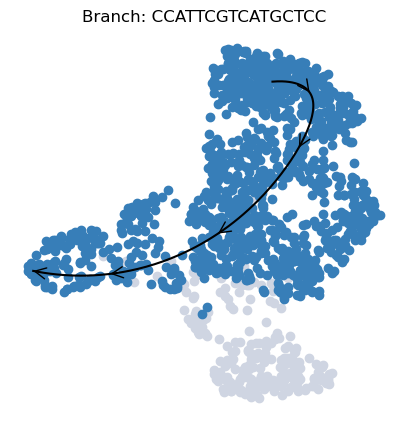

In [49]:
palantir.plot.plot_trajectory(adata, terminal_cell1)

[2026-06-22 15:03:17,718] [INFO    ] Using sparse Gaussian Process since n_landmarks (50) < n_samples (1,163) and rank = 1.0.
[2026-06-22 15:03:17,719] [INFO    ] Using covariance function Matern52(ls=0.9287169575691223).
[2026-06-22 15:03:17,739] [INFO    ] Computing 50 landmarks with k-means clustering (random_state=42).
[2026-06-22 15:03:18,397] [INFO    ] Sigma interpreted as element-wise standard deviation.


<Axes: title={'center': 'Branch: CCGTACTGTGGACGAT'}>

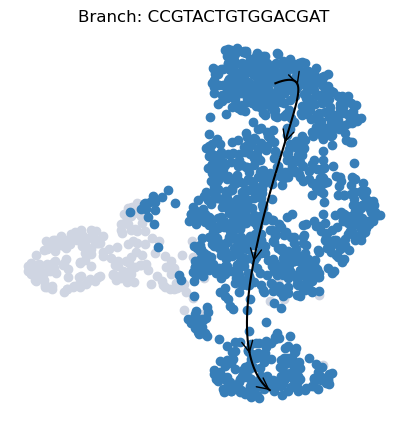

In [50]:
palantir.plot.plot_trajectory(adata, terminal_cell2)

In [51]:
gene_trends = palantir.presults.compute_gene_trends(adata, expression_key="MAGIC_imputed_data")

/home/FCAM/kcobb/.miniforge/envs/single-cell/lib/python3.11/site-packages/palantir/presults.py:270: FutureWarning: Use obs (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`) instead of AnnData.obs_keys, AnnData.obs_keys is deprecated and will be removed in the future.
  if pseudo_time_key not in ad.obs_keys():


CCATTCGTCATGCTCC
[2026-06-22 15:03:18,837] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (1,130) and rank = 1.0.
[2026-06-22 15:03:18,838] [INFO    ] Using covariance function Matern52(ls=1.0).
[2026-06-22 15:03:20,786] [INFO    ] Sigma interpreted as element-wise standard deviation.
CCGTACTGTGGACGAT
[2026-06-22 15:03:23,715] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (1,163) and rank = 1.0.
[2026-06-22 15:03:23,716] [INFO    ] Using covariance function Matern52(ls=1.0).
[2026-06-22 15:03:24,630] [INFO    ] Sigma interpreted as element-wise standard deviation.


In [52]:
hv_genes = adata.var_names[:500]
communities = palantir.presults.cluster_gene_trends(adata, terminal_cell1, hv_genes)

/home/FCAM/kcobb/.miniforge/envs/single-cell/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)


In [53]:
communities.head()

Gm8141    0
Exo1      1
Uxs1      2
Dsel      3
Gm6028    2
dtype: category
Categories (4, object): ['0', '1', '2', '3']

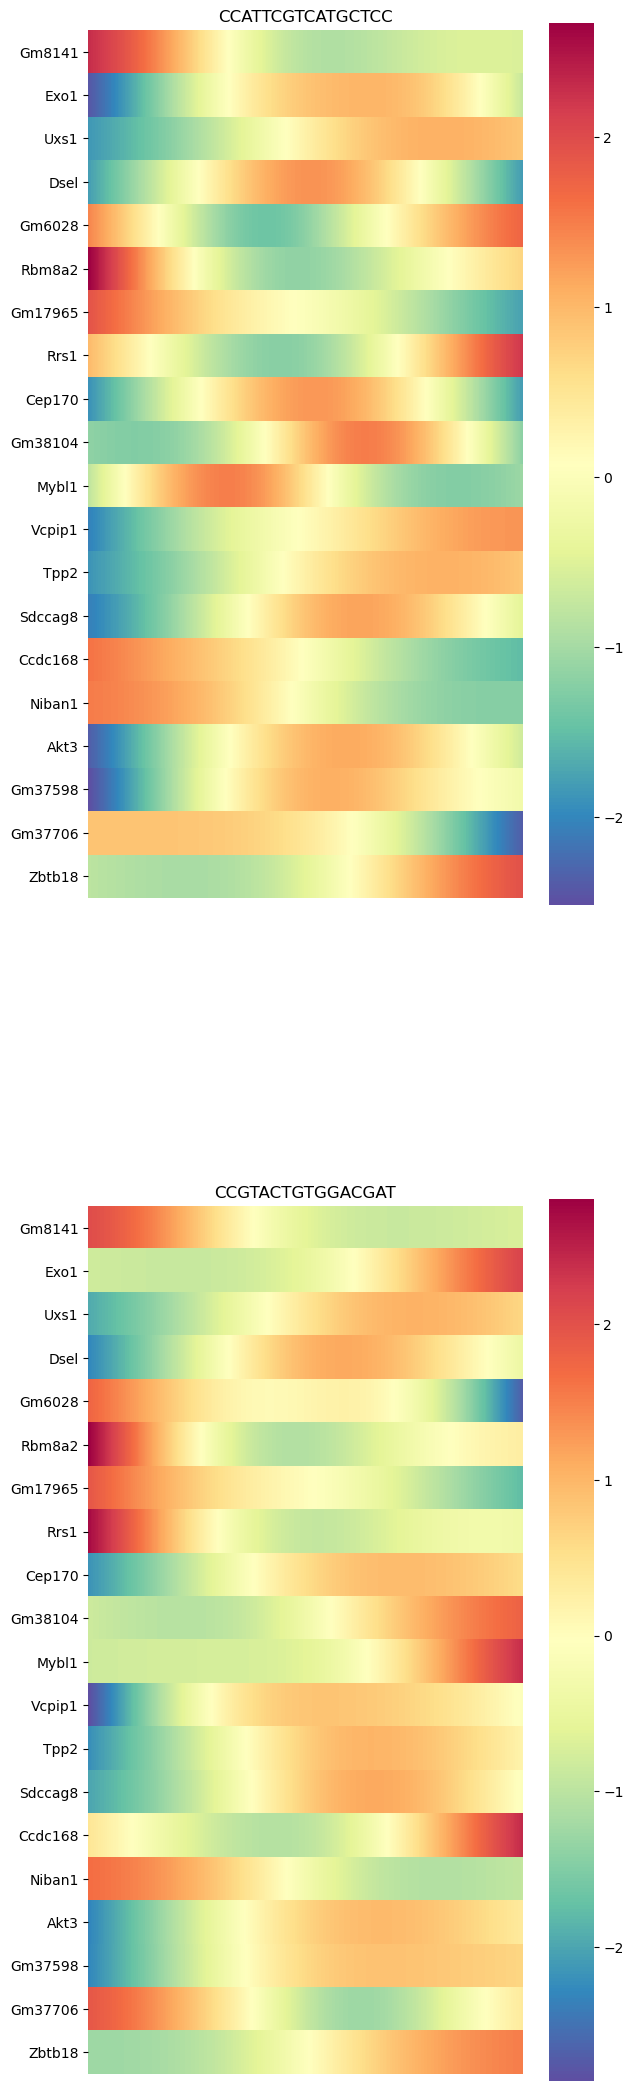

In [54]:
palantir.plot.plot_gene_trend_heatmaps(adata, hv_genes[:20])
plt.show()

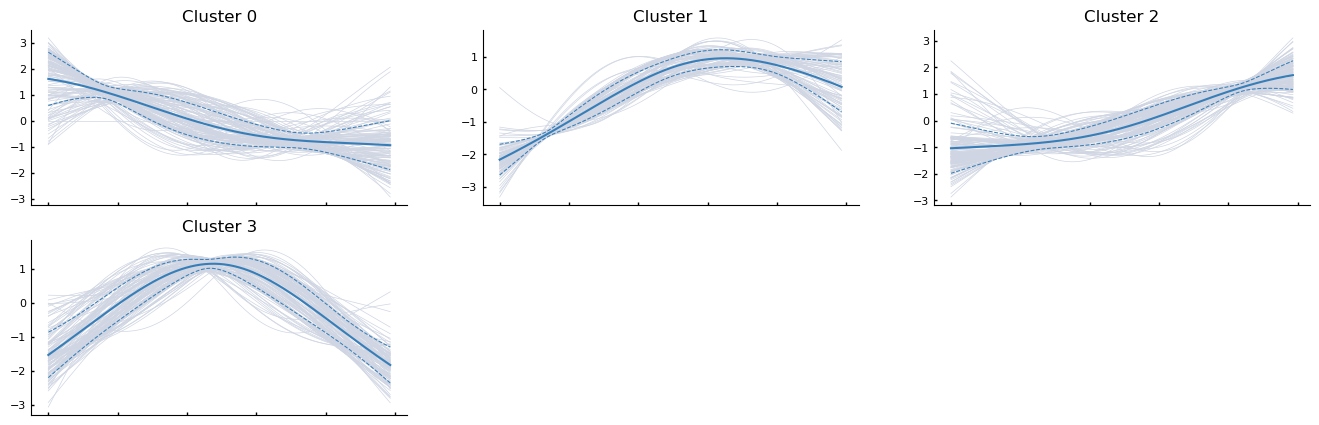

In [55]:
palantir.plot.plot_gene_trend_clusters(adata, terminal_cell1)
plt.show()



In [56]:
branch1_adata = adata[masks[:,0]]

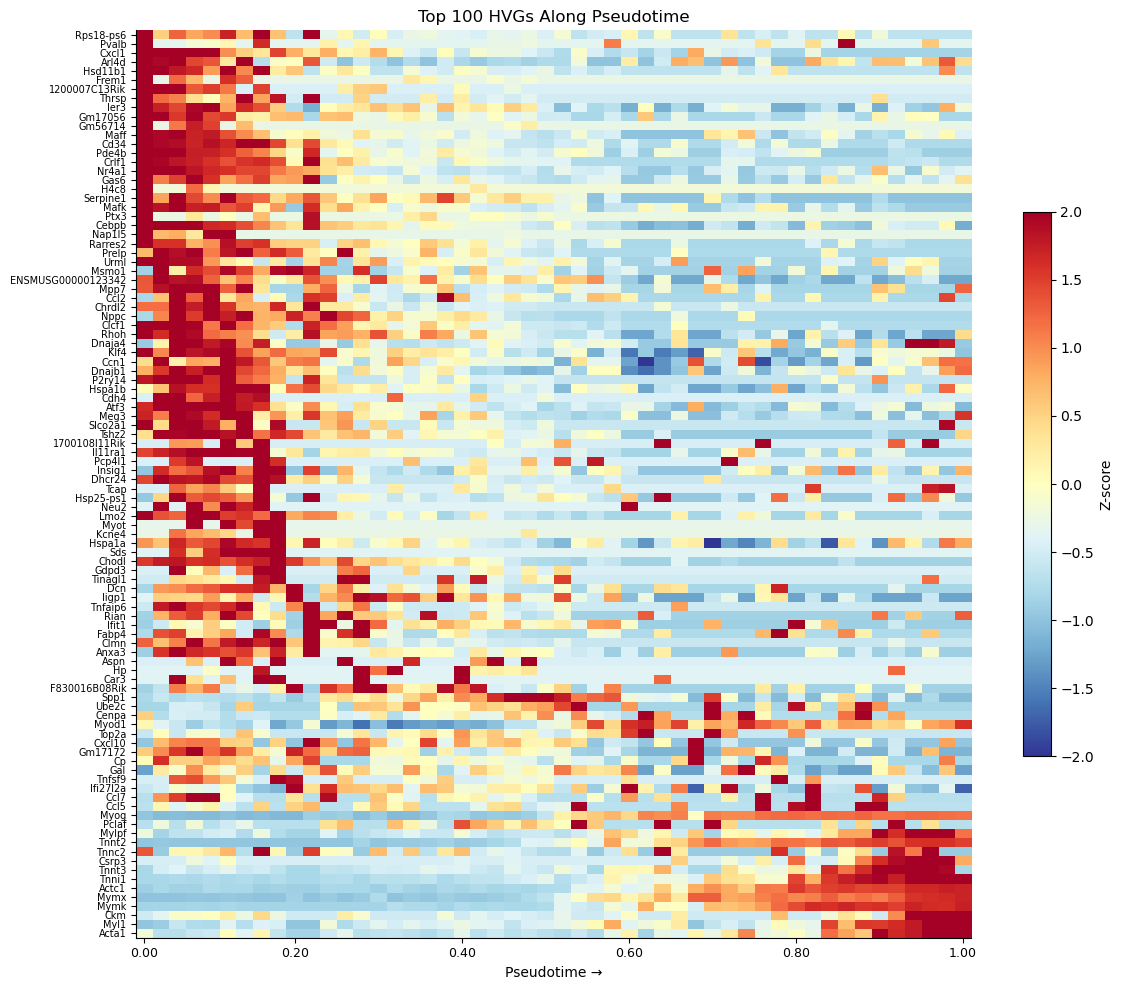

In [57]:
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d

N = 100 # Number of genes
n_bins = 50 # Number of bins
smooth_window = 1

# Select top N highly variable genes by normalized dispersion
top_genes = (
    branch1_adata.var[branch1_adata.var["highly_variable"]]
    .nlargest(N, "dispersions_norm")
    .index.tolist()
)

# Extract expression matrix
X = branch1_adata[:, top_genes].X
if hasattr(X, "toarray"):
    X = X.toarray()
X = np.array(X, dtype=float)

# Sort cells by pseudotime (drop NaN cells like the root)
pt = branch1_adata.obs["dpt_pseudotime"].values
valid = np.isfinite(pt)
X, pt = X[valid], pt[valid]
order = np.argsort(pt)
X_sorted, pt_sorted = X[order], pt[order]

# Bin cells along pseudotime and average
bins = np.linspace(pt_sorted.min(), pt_sorted.max(), n_bins + 1)
bin_idx = np.clip(np.digitize(pt_sorted, bins) - 1, 0, n_bins - 1)
X_binned = np.array([X_sorted[bin_idx == b].mean(axis=0) if (bin_idx == b).any()
                     else np.zeros(len(top_genes)) for b in range(n_bins)])

# Smooth and z-score each gene
X_binned = uniform_filter1d(X_binned, size=smooth_window, axis=0)
std = X_binned.std(axis=0)
std[std == 0] = 1
X_z = (X_binned - X_binned.mean(axis=0)) / std

# Order genes by peak expression bin
gene_order = np.argsort(np.argmax(X_z, axis=0))
X_z = X_z[:, gene_order]
genes_ordered = [top_genes[i] for i in gene_order]

# Plot
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(X_z.T, aspect="auto", cmap="RdYlBu_r", vmin=-2, vmax=2)
ax.set_yticks(range(len(genes_ordered)))
ax.set_yticklabels(genes_ordered, fontsize=7)
ax.set_xlabel("Pseudotime →")
ax.set_title(f"Top {N} HVGs Along Pseudotime")
xtick_pos = np.linspace(0, n_bins - 1, 6, dtype=int)
ax.set_xticks(xtick_pos)
ax.set_xticklabels([f"{pt_sorted.min() + (pt_sorted.max() - pt_sorted.min()) * i / 5:.2f}"
                    for i in range(6)], fontsize=9)
plt.colorbar(im, ax=ax, shrink=0.6, label="Z-score")
plt.tight_layout()
plt.show()

In [58]:
branch2_adata = adata[masks[:,1]]

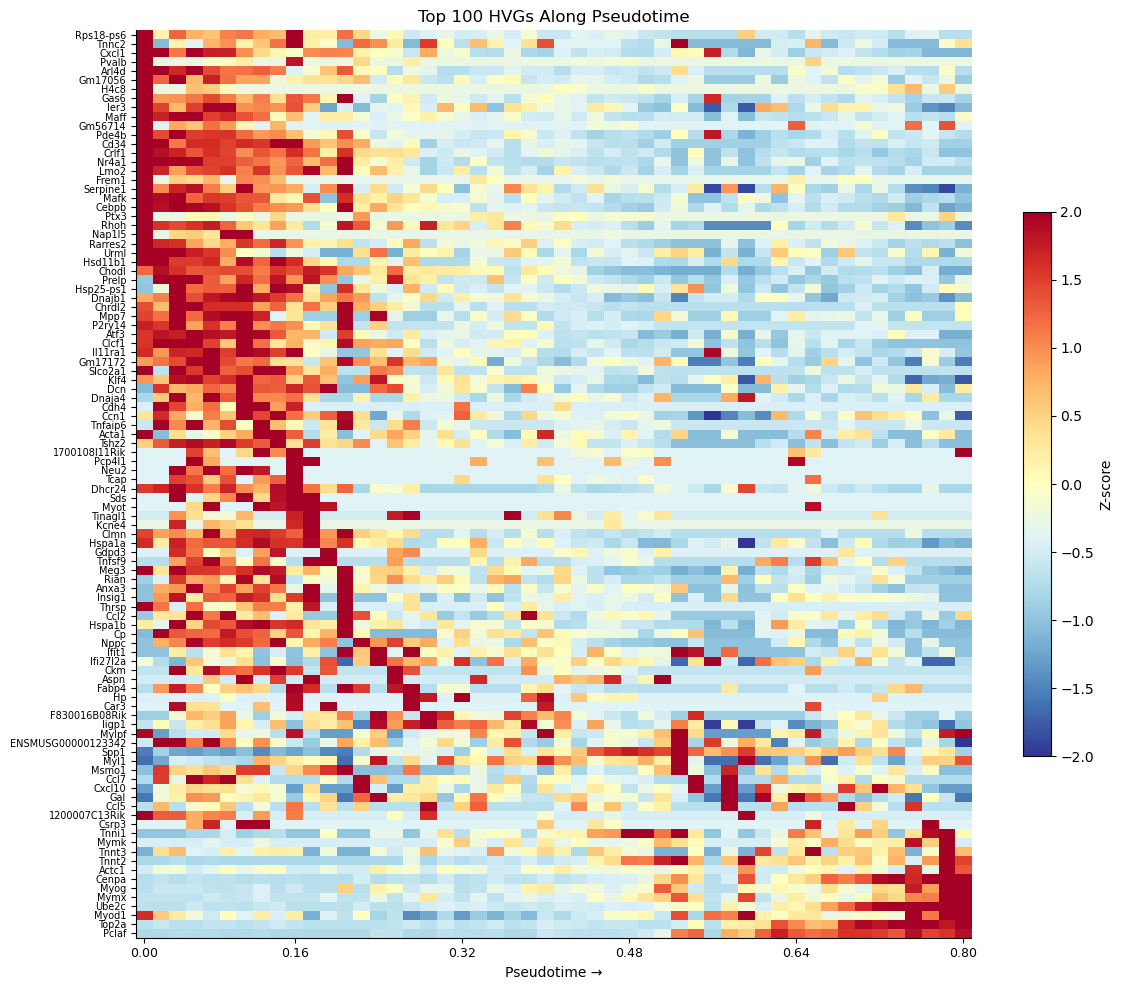

In [59]:
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d

N = 100 # Number of genes
n_bins = 50 # Number of bins
smooth_window = 1

# Select top N highly variable genes by normalized dispersion
top_genes = (
    branch2_adata.var[branch2_adata.var["highly_variable"]]
    .nlargest(N, "dispersions_norm")
    .index.tolist()
)

# Extract expression matrix
X = branch2_adata[:, top_genes].X
if hasattr(X, "toarray"):
    X = X.toarray()
X = np.array(X, dtype=float)

# Sort cells by pseudotime (drop NaN cells like the root)
pt = branch2_adata.obs["dpt_pseudotime"].values
valid = np.isfinite(pt)
X, pt = X[valid], pt[valid]
order = np.argsort(pt)
X_sorted, pt_sorted = X[order], pt[order]

# Bin cells along pseudotime and average
bins = np.linspace(pt_sorted.min(), pt_sorted.max(), n_bins + 1)
bin_idx = np.clip(np.digitize(pt_sorted, bins) - 1, 0, n_bins - 1)
X_binned = np.array([X_sorted[bin_idx == b].mean(axis=0) if (bin_idx == b).any()
                     else np.zeros(len(top_genes)) for b in range(n_bins)])

# Smooth and z-score each gene
X_binned = uniform_filter1d(X_binned, size=smooth_window, axis=0)
std = X_binned.std(axis=0)
std[std == 0] = 1
X_z = (X_binned - X_binned.mean(axis=0)) / std

# Order genes by peak expression bin
gene_order = np.argsort(np.argmax(X_z, axis=0))
X_z = X_z[:, gene_order]
genes_ordered = [top_genes[i] for i in gene_order]

# Plot
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(X_z.T, aspect="auto", cmap="RdYlBu_r", vmin=-2, vmax=2)
ax.set_yticks(range(len(genes_ordered)))
ax.set_yticklabels(genes_ordered, fontsize=7)
ax.set_xlabel("Pseudotime →")
ax.set_title(f"Top {N} HVGs Along Pseudotime")
xtick_pos = np.linspace(0, n_bins - 1, 6, dtype=int)
ax.set_xticks(xtick_pos)
ax.set_xticklabels([f"{pt_sorted.min() + (pt_sorted.max() - pt_sorted.min()) * i / 5:.2f}"
                    for i in range(6)], fontsize=9)
plt.colorbar(im, ax=ax, shrink=0.6, label="Z-score")
plt.tight_layout()
plt.show()